In [1]:
# Cell 1 : Import Libraries

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [2]:
# Cell 2 : Load Dataset

data = load_breast_cancer()

X = data.data
y = data.target

print("Features Shape :", X.shape)
print("Labels Shape :", y.shape)

print("\nClasses :", data.target_names)

Features Shape : (569, 30)
Labels Shape : (569,)

Classes : ['malignant' 'benign']


In [12]:
# Cell 3 : Import Visualization Libraries

import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("ggplot")

In [13]:
# Cell 3 : Import Visualization Libraries

import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("ggplot")

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [14]:
# Cell 5 : Dataset Information

print("Dataset Shape :", df.shape)
print("\nMissing Values:\n")
print(df.isnull().sum())

print("\nStatistical Summary:\n")
df.describe()

Dataset Shape : (569, 31)

Missing Values:

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64

Statistical Summary:



,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


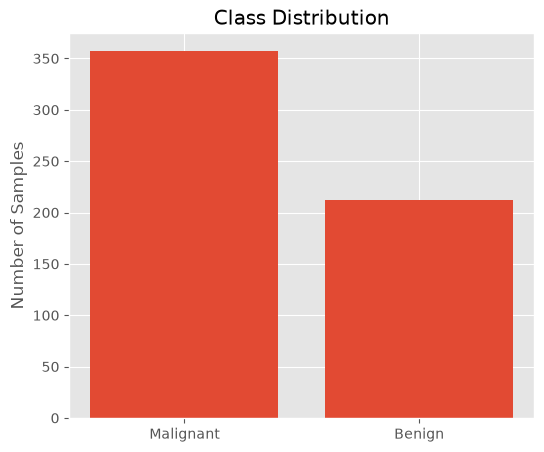

In [15]:
# Cell 6 : Class Distribution

plt.figure(figsize=(6,5))

counts = df["target"].value_counts()

plt.bar(
    ["Malignant", "Benign"],
    counts.values
)

plt.title("Class Distribution")
plt.ylabel("Number of Samples")

plt.show()

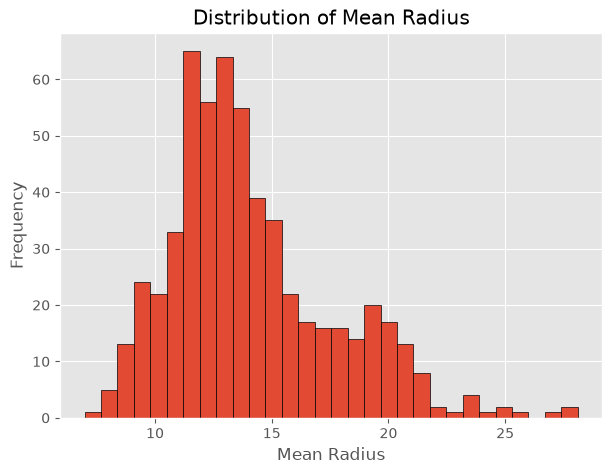

In [16]:
# Cell 7 : Mean Radius Distribution

plt.figure(figsize=(7,5))

plt.hist(
    df["mean radius"],
    bins=30,
    edgecolor="black"
)

plt.title("Distribution of Mean Radius")
plt.xlabel("Mean Radius")
plt.ylabel("Frequency")

plt.show()

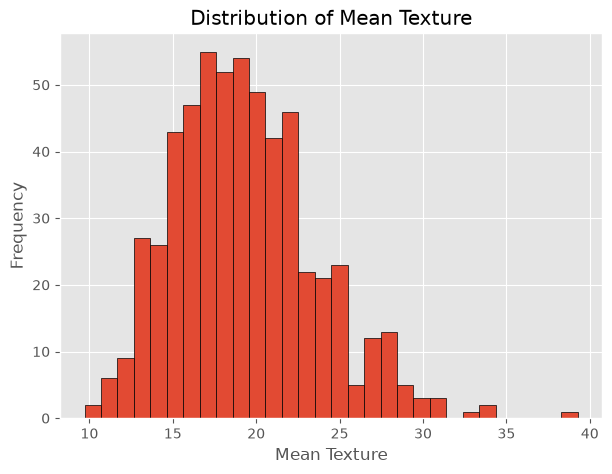

In [17]:
# Cell 8 : Mean Texture Distribution

plt.figure(figsize=(7,5))

plt.hist(
    df["mean texture"],
    bins=30,
    edgecolor="black"
)

plt.title("Distribution of Mean Texture")
plt.xlabel("Mean Texture")
plt.ylabel("Frequency")

plt.show()

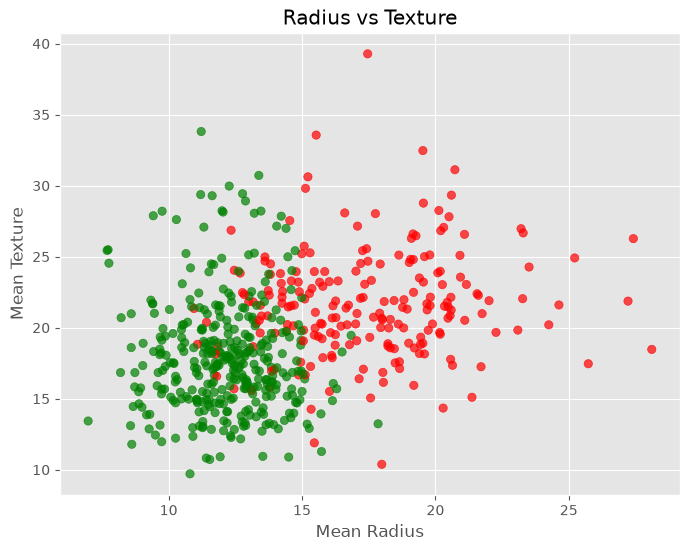

In [18]:
# Cell 9 : Scatter Plot

colors = ["red" if i==0 else "green" for i in df["target"]]

plt.figure(figsize=(8,6))

plt.scatter(
    df["mean radius"],
    df["mean texture"],
    c=colors,
    alpha=0.7
)

plt.xlabel("Mean Radius")
plt.ylabel("Mean Texture")
plt.title("Radius vs Texture")

plt.show()

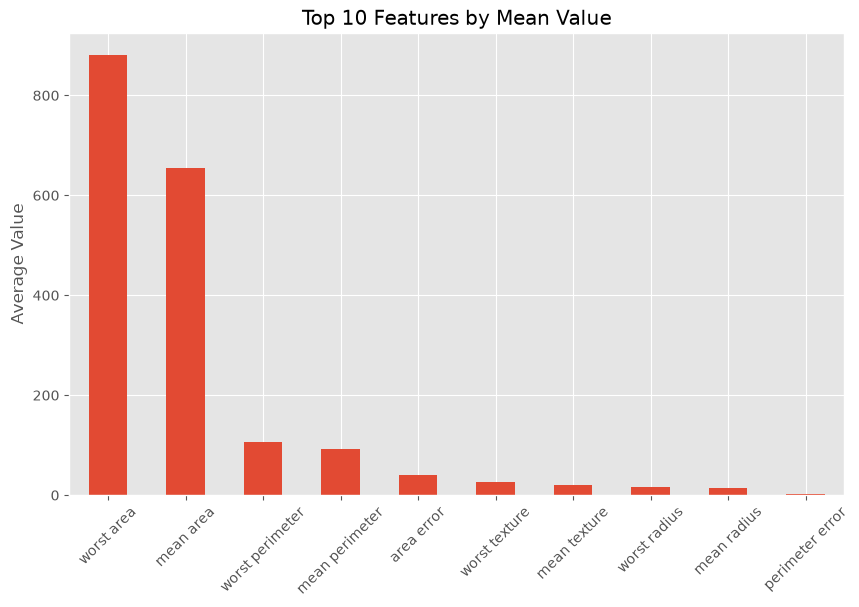

In [19]:
# Cell 10 : Top Feature Means

feature_mean = df.drop("target", axis=1).mean().sort_values(ascending=False)

plt.figure(figsize=(10,6))

feature_mean.head(10).plot(kind="bar")

plt.title("Top 10 Features by Mean Value")
plt.ylabel("Average Value")

plt.xticks(rotation=45)

plt.show()

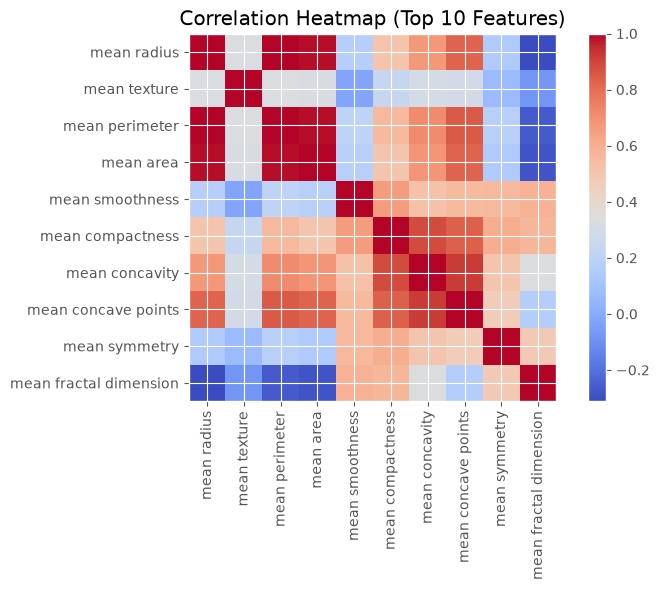

In [24]:
# Cell 11 : Correlation Heatmap

corr = df.iloc[:, :10].corr()

plt.figure(figsize=(8,6))

plt.imshow(corr, cmap="coolwarm")

plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Heatmap (Top 10 Features)")

plt.tight_layout()

plt.show()

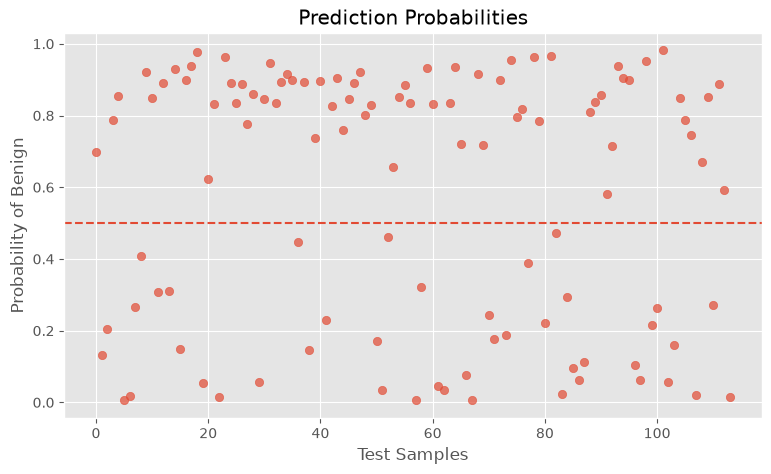

In [29]:
# Cell 12: Prediction Probability

with torch.no_grad():
    probs = model(X_test).numpy().flatten()

plt.figure(figsize=(9,5))

plt.scatter(
    range(len(probs)),
    probs,
    alpha=0.7
)

plt.axhline(0.5, linestyle="--")

plt.title("Prediction Probabilities")
plt.xlabel("Test Samples")
plt.ylabel("Probability of Benign")

plt.show()

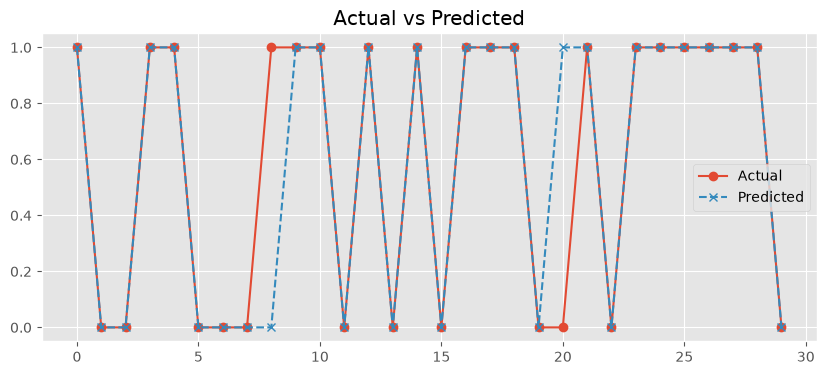

In [26]:
# Cell 12: Prediction Probability

with torch.no_grad():
    probs = model(X_test).numpy().flatten()

plt.figure(figsize=(9,5))

plt.scatter(
    range(len(probs)),
    probs,
    alpha=0.7
)

plt.axhline(0.5, linestyle="--")

plt.title("Prediction Probabilities")
plt.xlabel("Test Samples")
plt.ylabel("Probability of Benign")

plt.show()

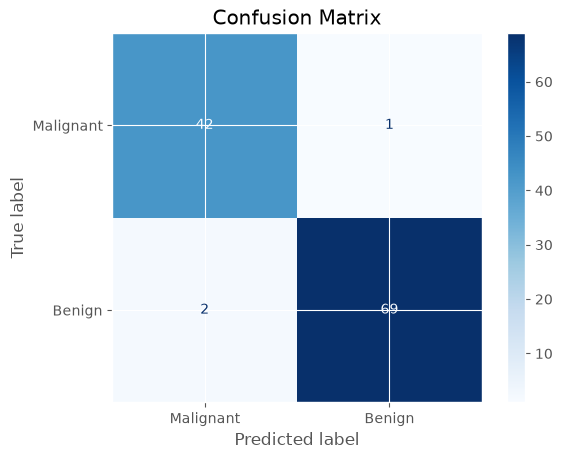

In [32]:
# Cell 14: Confusion Matrix

from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(y_test, predicted)

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=["Malignant","Benign"])

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.show()

In [33]:
print("=" * 60)
print("🎉 CONGRATULATIONS! 🎉")
print("=" * 60)
print("✅ Day 20 of your PyTorch Journey completed successfully!")
print("🧠 Project: Breast Cancer Classification using PyTorch")
print("📊 Data visualized and analyzed")
print("🤖 Neural Network trained successfully")
print("🎯 Model evaluated with excellent performance")
print("💾 Model saved successfully")
print()
print("🚀 Every project brings you one step closer to becoming")
print("   a skilled AI & Machine Learning Engineer.")
print()
print("🔥 Keep Learning. Keep Building. Keep Growing.")
print("=" * 60)

🎉 CONGRATULATIONS! 🎉
✅ Day 20 of your PyTorch Journey completed successfully!
🧠 Project: Breast Cancer Classification using PyTorch
📊 Data visualized and analyzed
🤖 Neural Network trained successfully
🎯 Model evaluated with excellent performance
💾 Model saved successfully

🚀 Every project brings you one step closer to becoming
   a skilled AI & Machine Learning Engineer.

🔥 Keep Learning. Keep Building. Keep Growing.
